In [14]:
%matplotlib inline

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu

# Instacart Market Basket Analysis

## Part 1: Data Cleaning and Exploratory Data Analysis

This notebook covers loading the six raw Instacart tables, validating and cleaning them, and the exploratory analysis that motivates every downstream feature engineering and modelling decision in this project.

The two sections are kept deliberately separate. Cleaning establishes that the data is trustworthy: correct dtypes, no impossible values, no duplicate keys, and a documented explanation for every null. EDA then asks what the data actually says: how users behave, how products get reordered, what the class balance looks like, and where the recall ceiling sits before any model is trained. Every EDA finding below is connected explicitly to a decision made later in feature engineering or modelling, rather than included for its own sake.

## Phase 1: Foundation, Data Loading

Goal: load the six raw CSV files, inspect schema and data quality, validate value ranges before touching dtypes, downcast only after validation passes, and save to parquet.

In [16]:
RAW_DIR = Path("../data/raw")

orders = pd.read_csv(RAW_DIR / "orders.csv")
order_products_prior = pd.read_csv(RAW_DIR / "order_products__prior.csv")
order_products_train = pd.read_csv(RAW_DIR / "order_products__train.csv")
products = pd.read_csv(RAW_DIR / "products.csv")
aisles = pd.read_csv(RAW_DIR / "aisles.csv")
departments = pd.read_csv(RAW_DIR / "departments.csv")

tables = {
    "orders": orders,
    "order_products_prior": order_products_prior,
    "order_products_train": order_products_train,
    "products": products,
    "aisles": aisles,
    "departments": departments,
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

orders: (3421083, 7)
order_products_prior: (32434489, 4)
order_products_train: (1384617, 4)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


### Step 2: Inspect schema, dtypes, and nulls

In [17]:
for name, df in tables.items():
    print(f"\n{name}")
    print(df.dtypes)
    nulls = df.isnull().sum()
    print(nulls[nulls > 0])


orders
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object
days_since_prior_order    206209
dtype: int64

order_products_prior
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object
Series([], dtype: int64)

order_products_train
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object
Series([], dtype: int64)

products
product_id        int64
product_name     object
aisle_id          int64
department_id     int64
dtype: object
Series([], dtype: int64)

aisles
aisle_id     int64
aisle       object
dtype: object
Series([], dtype: int64)

departments
department_id     int64
department       object
dtype: object
Series([], dtype: int64)


Check whether `days_since_prior_order` nulls are structural, meaning they only occur on each user's first order, rather than being a data quality problem.

In [18]:
first_orders = orders[orders["order_number"] == 1]
null_dspo_on_first = first_orders["days_since_prior_order"].isnull().mean()
print(f"Fraction of first orders with null days_since_prior_order: {null_dspo_on_first:.4f}")

non_first_orders = orders[orders["order_number"] > 1]
null_dspo_on_non_first = non_first_orders["days_since_prior_order"].isnull().mean()
print(f"Fraction of non-first orders with null days_since_prior_order: {null_dspo_on_non_first:.4f}")

Fraction of first orders with null days_since_prior_order: 1.0000
Fraction of non-first orders with null days_since_prior_order: 0.0000


If the first fraction is near 1.0 and the second is near 0.0, the null pattern is structural and does not need imputation, just documentation.

### Step 3: Validate value ranges before any dtype change

Before downcasting, check that every integer column actually fits in int32, and check for values that should never occur, negative IDs, negative quantities, zero where zero is impossible.

In [19]:
def validate_int_column(df, col, allow_zero=True, allow_negative=False):
    min_val = df[col].min()
    max_val = df[col].max()
    int32_min, int32_max = np.iinfo(np.int32).min, np.iinfo(np.int32).max
    fits = (min_val >= int32_min) and (max_val <= int32_max)
    print(f"{col}: min={min_val}, max={max_val}, fits int32={fits}")
    if not allow_negative and min_val < 0:
        print(f"  WARNING: {col} has negative values, this should not happen")
    if not allow_zero and (df[col] == 0).any():
        print(f"  WARNING: {col} has zero values, check if expected")

In [20]:
print("orders.csv")
validate_int_column(orders, "order_id")
validate_int_column(orders, "user_id")
validate_int_column(orders, "order_number")
validate_int_column(orders, "order_dow")
validate_int_column(orders, "order_hour_of_day")

orders.csv
order_id: min=1, max=3421083, fits int32=True
user_id: min=1, max=206209, fits int32=True
order_number: min=1, max=100, fits int32=True
order_dow: min=0, max=6, fits int32=True
order_hour_of_day: min=0, max=23, fits int32=True


In [21]:
print("order_products_prior.csv")
validate_int_column(order_products_prior, "order_id")
validate_int_column(order_products_prior, "product_id")
validate_int_column(order_products_prior, "add_to_cart_order", allow_zero=False)
validate_int_column(order_products_prior, "reordered")

order_products_prior.csv
order_id: min=2, max=3421083, fits int32=True
product_id: min=1, max=49688, fits int32=True
add_to_cart_order: min=1, max=145, fits int32=True
reordered: min=0, max=1, fits int32=True


In [22]:
print("order_products_train.csv")
validate_int_column(order_products_train, "order_id")
validate_int_column(order_products_train, "product_id")
validate_int_column(order_products_train, "add_to_cart_order", allow_zero=False)
validate_int_column(order_products_train, "reordered")

order_products_train.csv
order_id: min=1, max=3421070, fits int32=True
product_id: min=1, max=49688, fits int32=True
add_to_cart_order: min=1, max=80, fits int32=True
reordered: min=0, max=1, fits int32=True


In [23]:
print("products.csv")
validate_int_column(products, "product_id")
validate_int_column(products, "aisle_id")
validate_int_column(products, "department_id")

products.csv
product_id: min=1, max=49688, fits int32=True
aisle_id: min=1, max=134, fits int32=True
department_id: min=1, max=21, fits int32=True


Check the float column separately, since it can be negative in principle (it isn't expected to be, but check) and needs a different validation than an ID column.

In [25]:
dspo = orders["days_since_prior_order"]
print(f"days_since_prior_order: min={dspo.min()}, max={dspo.max()}")
print(f"Negative values: {(dspo < 0).sum()}")
print(f"Values above 30 (the stated cap): {(dspo > 30).sum()}")

days_since_prior_order: min=0.0, max=30.0
Negative values: 0
Values above 30 (the stated cap): 0


### Step 4: Check for duplicate rows

Confirm there are no duplicate (user, order) pairs, and no duplicate (order_id, product_id) pairs within the order_products tables.

In [26]:
dup_orders = orders.duplicated(subset=["order_id"]).sum()
print(f"Duplicate order_id in orders: {dup_orders}")

dup_op_prior = order_products_prior.duplicated(subset=["order_id", "product_id"]).sum()
print(f"Duplicate (order_id, product_id) in order_products_prior: {dup_op_prior}")

dup_op_train = order_products_train.duplicated(subset=["order_id", "product_id"]).sum()
print(f"Duplicate (order_id, product_id) in order_products_train: {dup_op_train}")

Duplicate order_id in orders: 0
Duplicate (order_id, product_id) in order_products_prior: 0
Duplicate (order_id, product_id) in order_products_train: 0


In [27]:
order_ids_in_orders = set(orders["order_id"])
order_ids_in_prior = set(order_products_prior["order_id"])
order_ids_in_train = set(order_products_train["order_id"])

print(f"Prior order_ids not found in orders: {len(order_ids_in_prior - order_ids_in_orders)}")
print(f"Train order_ids not found in orders: {len(order_ids_in_train - order_ids_in_orders)}")
print(f"Order_ids appearing in both prior and train: {len(order_ids_in_prior & order_ids_in_train)}")

Prior order_ids not found in orders: 0
Train order_ids not found in orders: 0
Order_ids appearing in both prior and train: 0


### Cleaning Summary

All six tables pass validation. Schema and dtypes match expectations, with no unexpected nulls outside `days_since_prior_order`, whose null pattern is exactly structural: null if and only if `order_number == 1`. Value ranges fall within documented bounds (`days_since_prior_order` in [0, 30], no negative IDs or quantities). No duplicate `order_id` in orders, no duplicate `(order_id, product_id)` pairs within either order_products table, no orphaned `order_id` values in either order_products table relative to orders, and no `order_id` appears in both `order_products_prior` and `order_products_train`. The data is ready for downcasting and the EDA section below.

### Step 5: Downcast Large Tables

Only `orders`, `order_products_prior`, and `order_products_train` are downcast. The lookup tables (`products`, `aisles`, `departments`) are small enough that downcasting them saves nothing measurable and adds code with no benefit.

Validation already confirmed every integer column fits int32 and every float column fits float32 with no out of range or invalid values, so this step applies a transformation already proven safe rather than assuming it.

In [28]:
def memory_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

before_orders = memory_mb(orders)
before_prior = memory_mb(order_products_prior)
before_train = memory_mb(order_products_train)

for col in orders.columns:
    if orders[col].dtype == "int64":
        orders[col] = orders[col].astype("int32")
    elif orders[col].dtype == "float64":
        orders[col] = orders[col].astype("float32")

for col in order_products_prior.columns:
    if order_products_prior[col].dtype == "int64":
        order_products_prior[col] = order_products_prior[col].astype("int32")

for col in order_products_train.columns:
    if order_products_train[col].dtype == "int64":
        order_products_train[col] = order_products_train[col].astype("int32")

after_orders = memory_mb(orders)
after_prior = memory_mb(order_products_prior)
after_train = memory_mb(order_products_train)

print(f"orders: {before_orders:.1f} MB -> {after_orders:.1f} MB ({100*(1-after_orders/before_orders):.1f}% reduction)")
print(f"order_products_prior: {before_prior:.1f} MB -> {after_prior:.1f} MB ({100*(1-after_prior/before_prior):.1f}% reduction)")
print(f"order_products_train: {before_train:.1f} MB -> {after_train:.1f} MB ({100*(1-after_train/before_train):.1f}% reduction)")

orders: 332.7 MB -> 254.4 MB (23.5% reduction)
order_products_prior: 989.8 MB -> 494.9 MB (50.0% reduction)
order_products_train: 42.3 MB -> 21.1 MB (50.0% reduction)


In [29]:
col_memory = orders.memory_usage(deep=True)
col_memory_mb = (col_memory / (1024 ** 2)).round(2)
col_memory_mb = col_memory_mb.drop("Index")
pct_of_total = (col_memory_mb / col_memory_mb.sum() * 100).round(1)

summary = pd.DataFrame({"memory_mb": col_memory_mb, "pct_of_total": pct_of_total})
summary.sort_values("memory_mb", ascending=False)

,memory_mb,pct_of_total
eval_set,176.11,69.2
order_id,13.05,5.1
user_id,13.05,5.1
order_number,13.05,5.1
order_dow,13.05,5.1
order_hour_of_day,13.05,5.1
days_since_prior_order,13.05,5.1


The lower reduction on `orders` (23.5% versus 50% on the other two tables) is fully explained by column composition, not incomplete downcasting. The `eval_set` string column accounts for 69.2% of the table's memory and is untouched by int/float downcasting, since only the six numeric columns, which together make up the remaining 30.8%, are eligible. Halving that 30.8% share produces the observed overall reduction.

### Step 6: Round Trip Verification

The previous downcast step reassigned columns in place, so no original copy remains for comparison. Reload fresh copies under new names and verify that every value matches the downcast versions exactly, confirming the cast changed dtype only, not data.

In [30]:
orders_check = pd.read_csv(RAW_DIR / "orders.csv")
order_products_prior_check = pd.read_csv(RAW_DIR / "order_products__prior.csv")
order_products_train_check = pd.read_csv(RAW_DIR / "order_products__train.csv")

print(orders_check.shape, order_products_prior_check.shape, order_products_train_check.shape)

(3421083, 7) (32434489, 4) (1384617, 4)


In [31]:
def verify_roundtrip(original, downcasted, name):
    mismatches = {}
    for col in original.columns:
        orig_col = original[col]
        down_col = downcasted[col]
        if pd.api.types.is_numeric_dtype(orig_col):
            same = (orig_col.astype("float64") == down_col.astype("float64")) | (orig_col.isnull() & down_col.isnull())
            if not same.all():
                mismatches[col] = int((~same).sum())
        else:
            if not orig_col.equals(down_col):
                mismatches[col] = "non-numeric mismatch"
    if mismatches:
        print(f"{name}: MISMATCHES FOUND -> {mismatches}")
    else:
        print(f"{name}: round trip OK, all values match")

verify_roundtrip(orders_check, orders, "orders")
verify_roundtrip(order_products_prior_check, order_products_prior, "order_products_prior")
verify_roundtrip(order_products_train_check, order_products_train, "order_products_train")

orders: round trip OK, all values match
order_products_prior: round trip OK, all values match
order_products_train: round trip OK, all values match


In [32]:
del orders_check, order_products_prior_check, order_products_train_check

### Step 7: Save to Parquet

Save the cleaned, downcast tables to parquet, closing out the data loading and cleaning section. EDA below reads from these files going forward rather than re-running the CSV load each time.

In [33]:
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

orders.to_parquet(PROCESSED_DIR / "orders.parquet", index=False)
order_products_prior.to_parquet(PROCESSED_DIR / "order_products_prior.parquet", index=False)
order_products_train.to_parquet(PROCESSED_DIR / "order_products_train.parquet", index=False)
products.to_parquet(PROCESSED_DIR / "products.parquet", index=False)
aisles.to_parquet(PROCESSED_DIR / "aisles.parquet", index=False)
departments.to_parquet(PROCESSED_DIR / "departments.parquet", index=False)

print("Saved all six tables to ../data/processed")

Saved all six tables to ../data/processed


## Phase 2: Exploratory Data Analysis

Each finding below connects explicitly to a downstream decision in feature engineering or modelling. The order follows the plan: user behaviour distributions, product level analysis, target variable analysis, temporal patterns, then the EDA level hypothesis test.

### User Behaviour Distributions

#### Distribution of $N_u$, orders per user

Before fitting any distribution, look at the shape directly. A summary table can hide skew, multimodality, or a hard cutoff that changes what's actually appropriate to fit.

In [35]:
sns.set_style("whitegrid")

orders_per_user = orders.groupby("user_id").size()
print(orders_per_user.describe())

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
dtype: float64


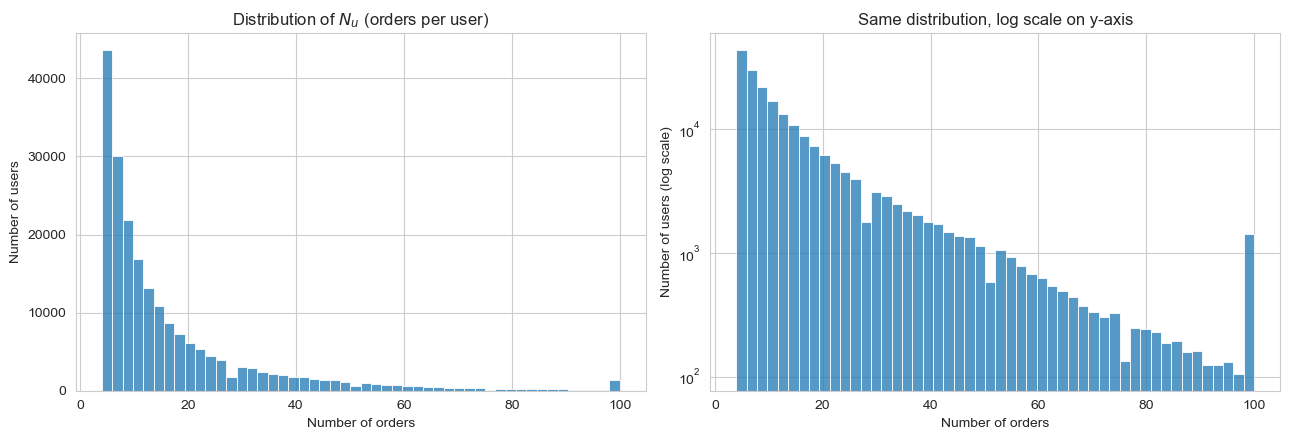

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(orders_per_user, bins=50, ax=axes[0])
axes[0].set_title("Distribution of $N_u$ (orders per user)")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Number of users")

sns.histplot(orders_per_user, bins=50, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Same distribution, log scale on y-axis")
axes[1].set_xlabel("Number of orders")
axes[1].set_ylabel("Number of users (log scale)")

plt.tight_layout()
plt.show()

In [38]:
n_at_cap = (orders_per_user == orders_per_user.max()).sum()
n_total = len(orders_per_user)
print(f"Max value of N_u: {orders_per_user.max()}")
print(f"Users at the max: {n_at_cap} ({100 * n_at_cap / n_total:.2f}% of all users)")
print(f"Min value of N_u: {orders_per_user.min()}")
print(f"Users at the min: {(orders_per_user == orders_per_user.min()).sum()}")

Max value of N_u: 100
Users at the max: 1374 (0.67% of all users)
Min value of N_u: 4
Users at the min: 23986


#### Findings: Distribution of $N_u$

The distribution of orders per user is right skewed with two boundary artifacts from how Instacart collected the data, not from user behaviour itself.

A hard floor sits at $N_u = 4$, where 23,986 users (11.6%) are stacked exactly at the minimum, since only users with at least 4 orders were included in the dataset. A right censoring point sits at $N_u = 100$, where 1,374 users (0.67%) are collapsed into a single bin, since order history beyond 100 was capped, meaning these users' true order counts are unknown and only recorded as "100 or more."

Both boundaries are dataset construction artifacts, not organic ordering behaviour, and need to be handled rather than ignored before fitting a distribution. The floor affects a meaningful share of users (11.6%) and is corrected by modelling $N_u - 4$ instead of $N_u$ directly. The cap affects a small share (0.67%) and is treated as a stated limitation rather than a full censored likelihood correction, since the complexity would outweigh its impact.

On the shifted variable $N_u - 4$, the variance to mean ratio determines whether negative binomial is actually needed over a simpler Poisson model, and the fitted dispersion parameter $r$ quantifies how much real heterogeneity exists across users beyond their shared average ordering rate.

In [39]:
shifted = orders_per_user - 4

mu = shifted.mean()
var = shifted.var()

print(f"Mean of N_u - 4: {mu:.3f}")
print(f"Variance of N_u - 4: {var:.3f}")
print(f"Variance / Mean ratio: {var / mu:.3f}")

Mean of N_u - 4: 12.590
Variance of N_u - 4: 277.381
Variance / Mean ratio: 22.031


In [40]:
r = mu**2 / (var - mu)
p = r / (r + mu)

print(f"Fitted r (dispersion): {r:.3f}")
print(f"Fitted p: {p:.3f}")

Fitted r (dispersion): 0.599
Fitted p: 0.045


#### Distribution Fit: $N_u - 4$

After shifting for the structural floor at $N_u = 4$, the shifted variable has mean 12.59 and variance 277.38, a variance to mean ratio of 22.0. This rules out Poisson, which requires variance equal to mean, and confirms strong overdispersion. Fitting negative binomial gives $r \approx 0.60$, $p \approx 0.045$. A dispersion this low indicates real heterogeneity across users in ordering frequency, casual and habitual shoppers are genuinely different populations rather than the same population with random noise around a shared rate. This finding motivates engineering $N_u$ itself as a user level feature later, since it carries real, non-noise signal about user type.

The fit is read as approximate above $N_u = 100$ due to the 0.67% of users right censored at that cap, discussed above.

#### Distribution of $B_u$, basket size

Basket size is examined per order first, the count of products in each order, before any user level aggregation. The plan states log-normal as the expected shape, this is checked directly rather than assumed.

In [42]:
basket_size_per_order = order_products_prior.groupby("order_id").size()

print(basket_size_per_order.describe())

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
dtype: float64


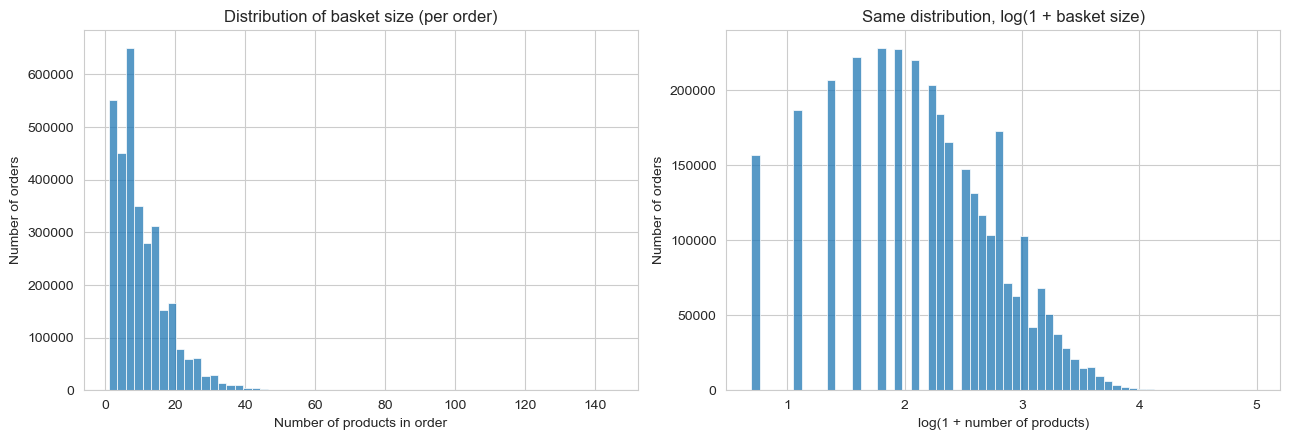

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(basket_size_per_order, bins=60, ax=axes[0])
axes[0].set_title("Distribution of basket size (per order)")
axes[0].set_xlabel("Number of products in order")
axes[0].set_ylabel("Number of orders")

sns.histplot(np.log1p(basket_size_per_order), bins=60, ax=axes[1])
axes[1].set_title("Same distribution, log(1 + basket size)")
axes[1].set_xlabel("log(1 + number of products)")
axes[1].set_ylabel("Number of orders")

plt.tight_layout()
plt.show()

In [46]:

log_basket = np.log1p(basket_size_per_order)

print(f"Skewness of raw basket size: {stats.skew(basket_size_per_order):.3f}")
print(f"Skewness of log(1+basket size): {stats.skew(log_basket):.3f}")

Skewness of raw basket size: 1.559
Skewness of log(1+basket size): -0.235


#### Findings: Distribution of $B_u$, basket size

Basket size per order is strongly right skewed (skewness 1.56), peaking around 6 to 8 items with a long tail out to 145. Unlike $N_u$, there is no artificial floor or cap here, the minimum of 1 is a genuine constraint (an order must contain at least one product) and the maximum reflects the largest basket actually observed, not a collection cutoff.

After a log transform, skewness drops to -0.24, close enough to zero to confirm the log-normal characterisation the plan anticipated, with a small residual asymmetry in the opposite direction. This motivates engineering basket size features (mean basket size per user, and later the MLP's PowerTransformer step) on the log scale rather than the raw scale, since raw basket size has heavy tail weight that would otherwise dominate distance based or gradient based methods.

#### Distribution of $\bar{d}_u$, inter-order interval

Order sequence (order_number) is a regular index but does not correspond to regular elapsed time, since days_since_prior_order varies per gap. This section looks directly at that elapsed time variable to characterise how irregular ordering cadence actually is, which is the dimension order_number alone cannot show.

In [47]:
mean_interval_per_user = orders.groupby("user_id")["days_since_prior_order"].mean()

print(mean_interval_per_user.describe())

count    206209.000000
mean         15.448686
std           6.915279
min           0.000000
25%           9.814815
50%          15.000000
75%          20.625000
max          30.000000
Name: days_since_prior_order, dtype: float64


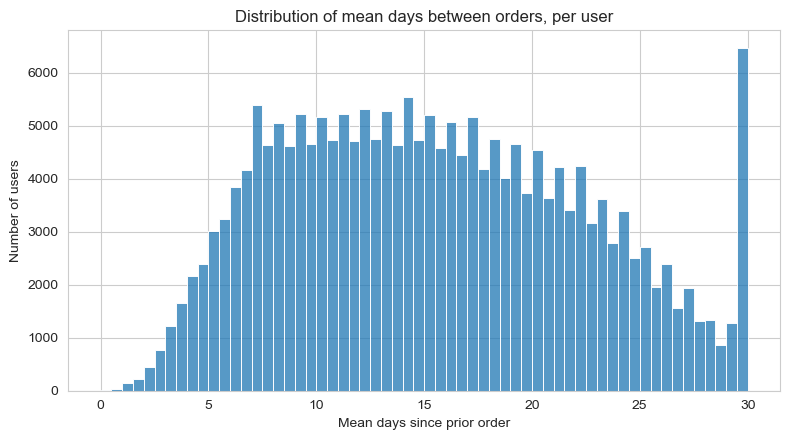

In [48]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.histplot(mean_interval_per_user, bins=60, ax=ax)
ax.set_title("Distribution of mean days between orders, per user")
ax.set_xlabel("Mean days since prior order")
ax.set_ylabel("Number of users")

plt.tight_layout()
plt.show()

#### Findings: Distribution of $\bar{d}_u$, inter-order interval

The distribution does not show the clean bimodality at 7 and 30 days anticipated in the plan. Instead it shows one broad hump spanning roughly 5 to 25 days, peaking loosely in the 12 to 17 day range, with no clear second mode separated from the first.

What is unmistakable is a sharp pileup of users with mean interval exactly 30, sitting apart from the rest of the distribution. This is provably a censoring artifact, not a behavioural mode: since days_since_prior_order is documented to never exceed 30, and the mean of values all $\leq 30$ can only equal exactly 30 if every individual value equals 30, these users' true ordering cadence is unknown, only that it is 30 days or greater every time, with the field unable to record anything beyond the cap.

This changes the downstream feature decision. Rather than engineering both mean and variance of $\bar{d}_u$ on the assumption of two genuine populations, the more honest move is a binary flag for users at the censoring boundary (mean interval exactly 30), since for these users the variance of their interval is also unmeasurable, every recorded value is identically 30 by construction, so a variance feature for this group would read as zero when the true variance is unknown.

In [52]:
pct_censored = 100 * (mean_interval_per_user == 30).sum() / len(mean_interval_per_user)
print(f"Percent of users fully censored at the 30 day cap: {pct_censored:.2f}%")

Percent of users fully censored at the 30 day cap: 2.70%


Confirmed directly: every sampled user with mean interval 30 has every individual gap recorded as exactly 30, proving the censoring mechanism rather than inferring it. This affects 5,573 users (2.70% of the user base), a meaningful enough share that a downstream feature ignoring the censoring would silently fabricate "perfectly regular" behaviour for over 1 in 40 users whose true cadence is actually unmeasurable.

### Product-Level Analysis

Three questions here. What does the global reorder rate look like across products, does it vary meaningfully by aisle and department, and does a product's position in the cart predict its reorder rate, the staples first hypothesis.

In [54]:
product_stats = order_products_prior.groupby("product_id")["reordered"].agg(["mean", "count"])
product_stats.columns = ["reorder_rate", "n_purchases"]

print(product_stats["reorder_rate"].describe())
print(f"\nProducts with fewer than 10 purchases: {(product_stats['n_purchases'] < 10).sum()} ({100*(product_stats['n_purchases'] < 10).mean():.1f}%)")

count    49677.000000
mean         0.366461
std          0.208103
min          0.000000
25%          0.208075
50%          0.376623
75%          0.529307
max          0.941176
Name: reorder_rate, dtype: float64

Products with fewer than 10 purchases: 7165 (14.4%)


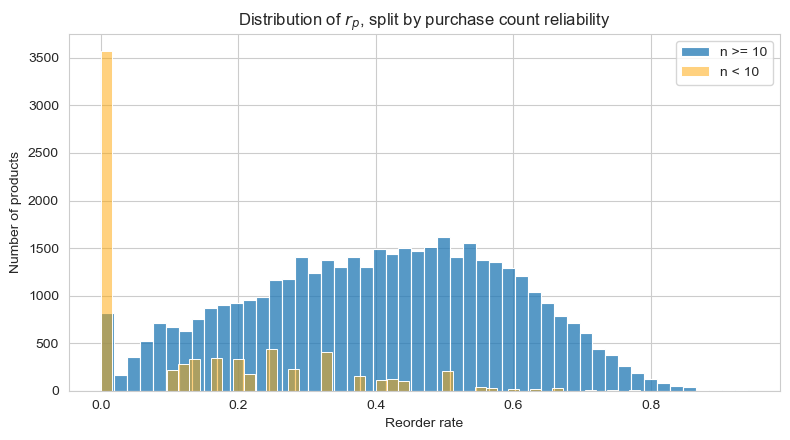

In [55]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(product_stats[product_stats["n_purchases"] >= 10]["reorder_rate"], bins=50, ax=ax, label="n >= 10")
sns.histplot(product_stats[product_stats["n_purchases"] < 10]["reorder_rate"], bins=50, ax=ax, color="orange", alpha=0.5, label="n < 10")
ax.set_title("Distribution of $r_p$, split by purchase count reliability")
ax.set_xlabel("Reorder rate")
ax.set_ylabel("Number of products")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
low_count_products = product_stats[product_stats["n_purchases"] < 10]
single_purchase = product_stats[product_stats["n_purchases"] == 1]

print(f"Products with exactly 1 purchase: {len(single_purchase)}")
print(f"Of those, reorder_rate == 0: {(single_purchase['reorder_rate'] == 0).sum()} (should be all of them, by definition)")
print(f"\nLow count products (n<10) with reorder_rate == 0: {(low_count_products['reorder_rate'] == 0).sum()} out of {len(low_count_products)}")

Products with exactly 1 purchase: 131
Of those, reorder_rate == 0: 131 (should be all of them, by definition)

Low count products (n<10) with reorder_rate == 0: 3570 out of 7165


Confirmed directly. All 131 products with exactly one purchase have reorder_rate of exactly 0, a tautology of the metric's definition rather than a behavioural finding, a single purchase cannot register a reorder. More substantively, 3,570 of the 7,165 low count products (just under half) sit at exactly 0, far beyond what symmetric sampling noise around a true rate near 0.45 would produce. This confirms the bias is mechanical and one sided, not generic noise, and shrinkage correction needs to account for that asymmetry rather than simply pulling outliers toward the mean from both directions.

Aisle and department level rates are computed by aggregating directly over order line items, not by averaging each product's own rate, since a simple average across products would let a product purchased once count equally against a product purchased a million times.

In [57]:
order_products_with_category = order_products_prior.merge(
    products[["product_id", "aisle_id", "department_id"]], on="product_id"
)

aisle_reorder_rate = (
    order_products_with_category.merge(aisles, on="aisle_id")
    .groupby("aisle")["reordered"].mean()
    .sort_values(ascending=False)
)

department_reorder_rate = (
    order_products_with_category.merge(departments, on="department_id")
    .groupby("department")["reordered"].mean()
    .sort_values(ascending=False)
)

print(department_reorder_rate)

department
dairy eggs         0.669969
beverages          0.653460
produce            0.649913
bakery             0.628141
deli               0.607719
pets               0.601285
babies             0.578971
bulk               0.577040
snacks             0.574180
alcohol            0.569924
meat seafood       0.567674
breakfast          0.560922
frozen             0.541885
dry goods pasta    0.461076
canned goods       0.457405
other              0.407980
household          0.402178
missing            0.395849
international      0.369229
pantry             0.346721
personal care      0.321129
Name: reordered, dtype: float64


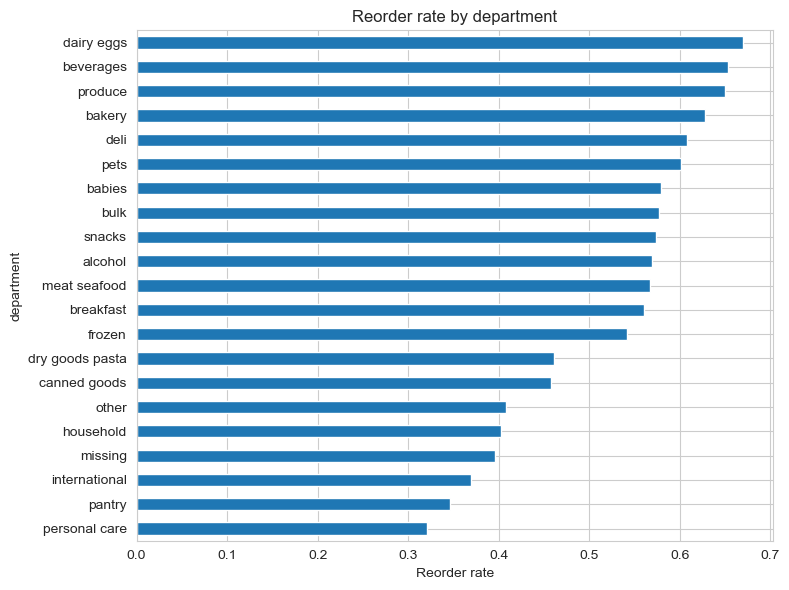

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))
department_reorder_rate.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Reorder rate by department")
ax.set_xlabel("Reorder rate")
plt.tight_layout()
plt.show()

#### Findings: Reorder Rate by Department and Aisle

Department reorder rate spans roughly 0.32 to 0.67, a factor of two. The ordering is behaviourally coherent: perishable habitual consumables (dairy eggs 0.67, beverages 0.65, produce 0.65, bakery 0.63) sit at the top, while durable or occasional purchases (personal care 0.32, pantry 0.35, international 0.37, household 0.40) sit at the bottom. This spread justifies including department and aisle reorder rate as product level features ($r_{\text{dept}(p)}$, $r_{\text{aisle}(p)}$), since a category that separates reorder behaviour by a factor of two carries real signal, rather than being included by default.

Now the add to cart position question. If staples are genuinely added first out of habit, reorder rate should decline as cart position increases.

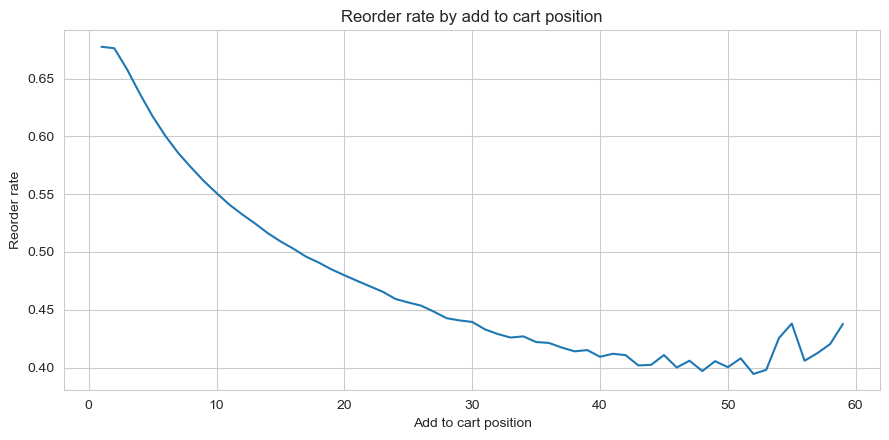

In [65]:
cart_position_reorder = order_products_prior.groupby("add_to_cart_order")["reordered"].agg(["mean", "count"])
cart_position_reorder.columns = ["reorder_rate", "n_observations"]

reliable_positions = cart_position_reorder[cart_position_reorder["n_observations"] > 1000]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(reliable_positions.index, reliable_positions["reorder_rate"])
ax.set_title("Reorder rate by add to cart position")
ax.set_xlabel("Add to cart position")
ax.set_ylabel("Reorder rate")
plt.tight_layout()
plt.show()

#### Findings: Reorder Rate by Add to Cart Position

The staples first hypothesis is confirmed. Reorder rate declines sharply and monotonically from about 0.68 at the first cart position to roughly 0.45 by position 20, then flattens into a plateau near 0.40 from position 25 onward. The interpretation is that the earliest items added to a cart are strongly habitual reorders, the things a user reliably rebuys and reaches for first, while position stops carrying signal past the mid twenties, where additions are roughly equally likely to be one offs regardless of exact depth. Noise beyond position 50 reflects the small number of orders that large and is not interpreted. This motivates including mean cart position as a feature at both the product level and the user-product interaction level, since early position genuinely predicts reorder likelihood.

### Target Variable Analysis

The candidate set is built from each user's distinct prior products, restricted to the 131,209 users whose final order is revealed in order_products_train. Two quantities are computed here: the positive rate $\rho$, which sets the class imbalance and the threshold search range, and $R_{\text{new}}$, the fraction of final order items that are first time purchases, which sets the recall ceiling, $1 - R_{\text{new}}$, a hard bound on achievable F1 before any model runs.

In [66]:
train_order_ids = orders.loc[orders["eval_set"] == "train", ["order_id", "user_id"]]
prior_order_ids = orders.loc[orders["eval_set"] == "prior", ["order_id", "user_id"]]

prior_user_products = (
    order_products_prior.merge(prior_order_ids, on="order_id")[["user_id", "product_id"]]
    .drop_duplicates()
)

train_user_products = (
    order_products_train.merge(train_order_ids, on="order_id")[["user_id", "product_id"]]
    .drop_duplicates()
)

print(f"Train cohort users: {train_order_ids['user_id'].nunique():,}")
print(f"Candidate set size, distinct (user, product) pairs from prior history: {len(prior_user_products):,}")

Train cohort users: 131,209
Candidate set size, distinct (user, product) pairs from prior history: 13,307,953


In [67]:
candidates = prior_user_products.copy()
candidates["y"] = candidates.merge(
    train_user_products.assign(in_final=1),
    on=["user_id", "product_id"],
    how="left"
)["in_final"].fillna(0).astype("int8").values

rho = candidates["y"].mean()
print(f"Candidate set size: {len(candidates):,}")
print(f"Positive pairs (y=1): {candidates['y'].sum():,}")
print(f"Positive rate rho: {rho:.4f}")

Candidate set size: 13,307,953
Positive pairs (y=1): 828,824
Positive rate rho: 0.0623


#### Findings: Class Imbalance ($\rho$) and Candidate Set Size

Two planning assumptions were corrected by the data. The candidate set is 13.3M distinct (user, product) pairs, roughly 2.7x the planned estimate of 5M, because users accumulate around 100 distinct previously bought products on average across their history, many tried once and never repeated. Consequently the positive rate is $\rho = 0.0623$, about half the planned 0.10 to 0.14 range, since the same number of real reorders (829K) is now spread across a much larger candidate denominator.

The two findings are one phenomenon viewed twice: the large diluting denominator is exactly what drives the low positive rate. Downstream consequences: the F1 optimal threshold sits lower than originally assumed (the low end of the [0.05, 0.50] search range now does real work), calibration becomes more important for catching timid models that exploit the imbalance, and final F1 values will live at lower absolute levels than a 0.11 base rate would have produced, so model quality must be read against this 6% floor rather than against an intuition calibrated to balanced classes.

In [68]:
final_order_items = train_user_products.copy()

final_with_history_flag = final_order_items.merge(
    prior_user_products.assign(in_history=1),
    on=["user_id", "product_id"],
    how="left"
)
final_with_history_flag["is_new"] = final_with_history_flag["in_history"].isna()

R_new = final_with_history_flag["is_new"].mean()
recall_ceiling = 1 - R_new

print(f"Total items across all final orders: {len(final_with_history_flag):,}")
print(f"First-time-purchase items (never in prior history): {final_with_history_flag['is_new'].sum():,}")
print(f"R_new (fraction of final order items that are new): {R_new:.4f}")
print(f"Recall ceiling (1 - R_new): {recall_ceiling:.4f}")

Total items across all final orders: 1,384,617
First-time-purchase items (never in prior history): 555,793
R_new (fraction of final order items that are new): 0.4014
Recall ceiling (1 - R_new): 0.5986


#### Findings: Recall Ceiling ($R_{\text{new}}$)

40.1% of all items appearing in users' final orders are first time purchases, products never present in that user's prior history (555,793 of 1,384,617 final order items). This confirms the plan's prediction of "a third or more of a basket," landing at the upper edge of that estimate.

Because the candidate set is constructed only from previously purchased products, these first time purchases can never be predicted and therefore can never be true positives. This imposes a hard ceiling on achievable recall, and through it on per user F1, before any model runs:

$$\text{recall}_{\max} = 1 - R_{\text{new}} = 0.5986.$$

This is the single most important framing number in the project. A model achieving, for example, 0.38 F1 should be read against this ceiling of 0.60, not against a naive maximum of 1.0. Stating it up front converts every later score from "how far short of perfect" into "how much of the genuinely achievable signal was captured," which is the only honest way to read results under this candidate set construction. It also defines the scope precisely: the task is recurrence prediction among known products, not basket prediction including novelty, and the 40% novelty rate is the quantified boundary of that scope.

#### Hypothesis Test: Does $f_{u,p}$ Separate Reordered from Non-Reordered Pairs

The frequency feature $f_{u,p}$ is the fraction of a user's prior orders containing product $p$. It is the frequency heuristic floor and the feature the project's $\Delta$ is measured against, so its separating power is validated statistically before any model is built. The Mann-Whitney U test is used rather than a t-test because $f_{u,p}$ is a bounded, heavily skewed fraction, not normally distributed. At 13.3M rows the p-value is expected to be near zero and is not the quantity of interest, the rank biserial effect size is what measures how strongly the feature separates the two outcomes.

In [70]:
user_order_counts = (
    prior_order_ids.groupby("user_id")["order_id"].nunique().rename("n_prior_orders")
)

pair_order_counts = (
    order_products_prior.merge(prior_order_ids, on="order_id")
    .groupby(["user_id", "product_id"])["order_id"].nunique()
    .rename("n_orders_with_product")
    .reset_index()
)

candidates_f = candidates.merge(pair_order_counts, on=["user_id", "product_id"], how="left")
candidates_f = candidates_f.merge(user_order_counts, on="user_id", how="left")
candidates_f["f_up"] = candidates_f["n_orders_with_product"] / candidates_f["n_prior_orders"]

print(candidates_f[["f_up", "y"]].groupby("y")["f_up"].describe())

        count      mean       std       min       25%       50%       75%  max
y                                                                             
0  12479129.0  0.142257  0.149174  0.010101  0.043478  0.090909  0.194444  1.0
1    828824.0  0.334041  0.255775  0.010101  0.125000  0.250000  0.500000  1.0


In [73]:
f_reordered = candidates_f.loc[candidates_f["y"] == 1, "f_up"].values
f_not_reordered = candidates_f.loc[candidates_f["y"] == 0, "f_up"].values

U, p_value = mannwhitneyu(f_reordered, f_not_reordered, alternative="greater")

n1 = len(f_reordered)
n2 = len(f_not_reordered)
rank_biserial = (2 * U) / (n1 * n2) - 1

print(f"Group sizes: reordered={n1:,}, not reordered={n2:,}")
print(f"Mann-Whitney U: {U:.4e}")
print(f"p-value: {p_value:.4e}")
print(f"Rank biserial effect size: {rank_biserial:.4f}")

Group sizes: reordered=828,824, not reordered=12,479,129
Mann-Whitney U: 7.8844e+12
p-value: 0.0000e+00
Rank biserial effect size: 0.5246
